                               order_id  customer_id  product_id     category  \
0  b8ec9f86-5919-4b71-a5f7-945e7c0a3db0         2031         845        Books   
1  5ea92c47-c5b2-4bdd-8a50-d77efd77ec89         2350         995  Electronics   
2  5cc48ce0-2c6d-4448-af3f-96f8a910d45b         1818         997       Beauty   
3  74d5c0f4-53f0-4367-a5c5-baaa114c2d9f          472         385         Home   
4  7a630323-8ac8-406e-875a-4bcdead440ab         1075          31     Clothing   

    price  quantity                  order_date               shipping_date  \
0   45.95         4  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
1  403.17         3  2024-04-20 14:59:58.897063  2024-04-22 14:59:58.897063   
2  317.45         2  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
3   24.08         3  2024-04-20 14:59:58.897063  2024-04-24 14:59:58.897063   
4  494.90         1  2024-04-20 14:59:58.897063  2024-04-25 14:59:58.897063   

  delivery_status payment_method devic

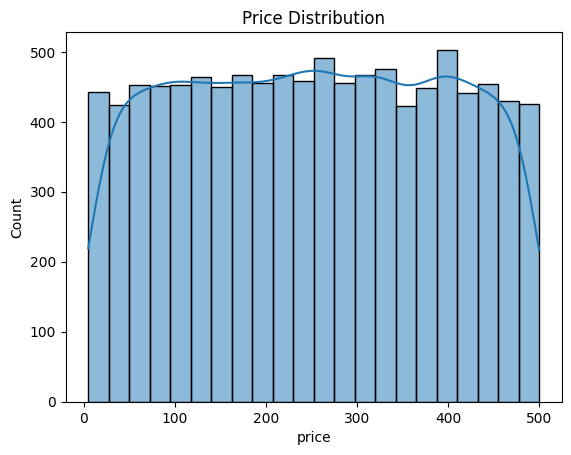

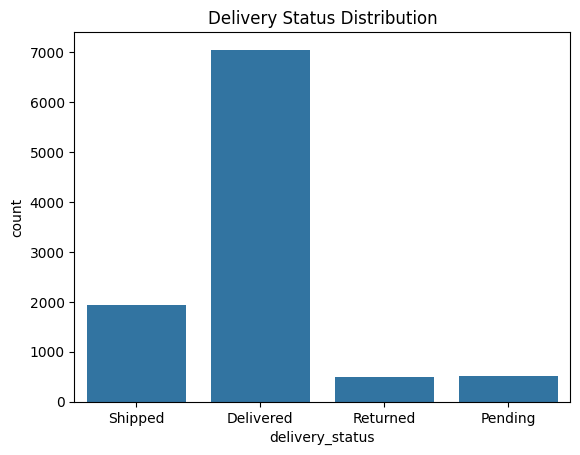

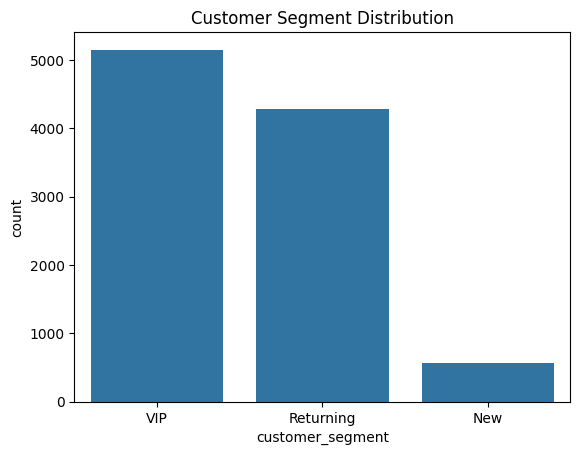

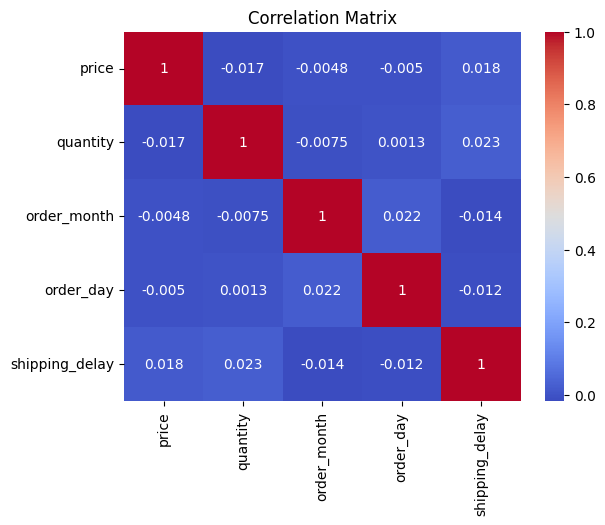

In [3]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("../project/ecommerce_orders_raw_data.csv")

print(df.head())
print(df.info())

# ================================
# DROP USELESS COLUMNS
# ================================
df = df.drop(columns=[
    "order_id",
    "customer_id",
    "product_id",
    "shipping_address",
    "billing_address"
])

# ================================
# FEATURE ENGINEERING (DATES)
# ================================
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["shipping_delay"] = (df["shipping_date"] - df["order_date"]).dt.days

df = df.drop(columns=["order_date", "shipping_date"])

# ================================
# EDA VISUALIZATION
# ================================
plt.figure()
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Distribution")
plt.show()

plt.figure()
sns.countplot(x="customer_segment", data=df)
plt.title("Customer Segment Distribution")
plt.show()

# Correlation heatmap
plt.figure()
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ================================
# DEFINE FEATURES
# ================================
X = df.drop(columns=["price", "delivery_status", "customer_segment"])

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

# ================================
# PREPROCESSING PIPELINE
# ================================
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-null  int64  
 2   product_id        10000 non-null  int64  
 3   category          10000 non-null  object 
 4   price             10000 non-null  float64
 5   quantity          10000 non-null  int64  
 6   order_date        10000 non-null  object 
 7   shipping_date     10000 non-null  object 
 8   delivery_status   10000 non-null  object 
 9   payment_method    10000 non-null  object 
 10  device_type       10000 non-null  object 
 11  channel           10000 non-null  object 
 12  shipping_address  10000 non-null  object 
 13  billing_address   10000 non-null  object 
 14  customer_segment  10000 non-null  object 
dtypes: float64(1), int64(3), object(11)
memory usage: 1.1+ MB


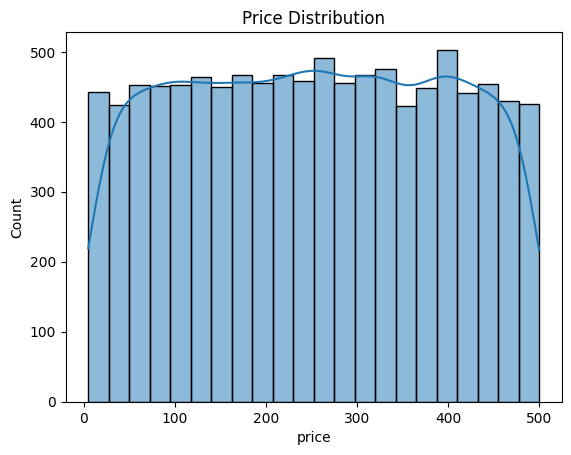

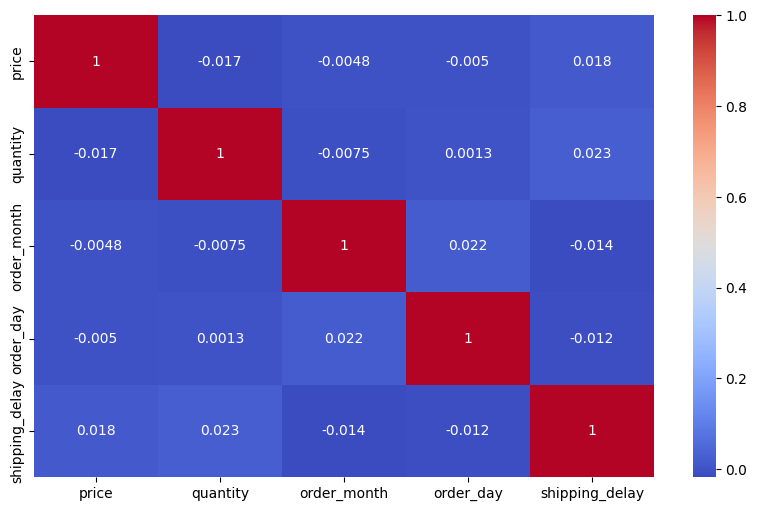

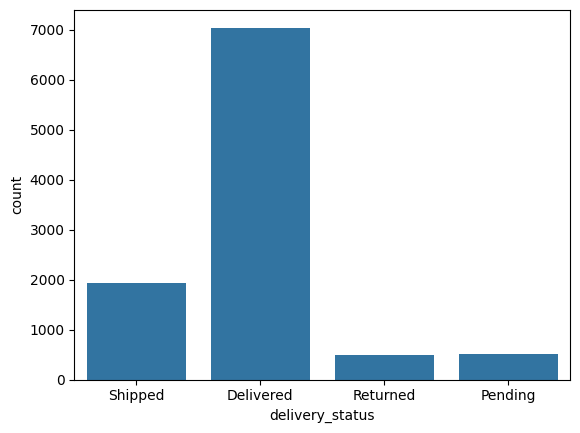

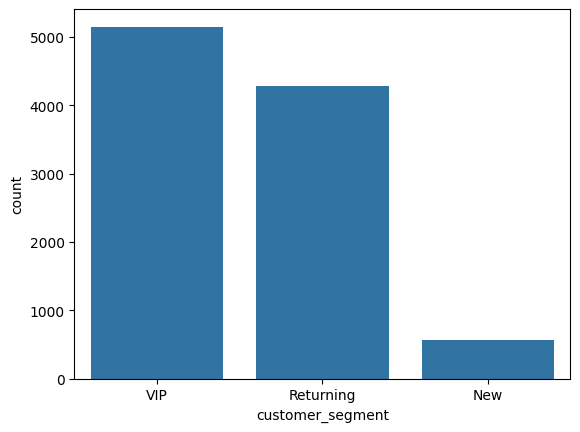

Transformed Shape: (10000, 29)


In [2]:
# Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../project/ecommerce_orders_raw_data.csv")

df.head()
df.info()

# Drop Unnecessary Columns
df = df.drop(columns=[
    "order_id",
    "customer_id",
    "product_id",
    "shipping_address",
    "billing_address"
])

# Feature Engineering (Dates)
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["shipping_delay"] = (df["shipping_date"] - df["order_date"]).dt.days

df = df.drop(columns=["order_date", "shipping_date"])

# EDA Numerical Distribution
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Categorical Distribution
sns.countplot(x="delivery_status", data=df)
plt.show()

sns.countplot(x="customer_segment", data=df)
plt.show()

# Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop(columns=["price"])

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Test Pipeline
X_transformed = preprocessor.fit_transform(X)
print("Transformed Shape:", X_transformed.shape)